In [38]:
# ============================================================
# PHASE 3 — EXPLORATION & ANALYSE STATISTIQUE (EDA)
# Dataset : Olist Brazilian E-Commerce
# ============================================================

# ── 0. IMPORTS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# ── 1. CHARGEMENT DES DONNÉES (issues de Phase 2) ───────────
orders        = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date'])
order_items   = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
order_payments= pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
customers     = pd.read_csv('../data/raw/olist_customers_dataset.csv')
products      = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers       = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
category_tr   = pd.read_csv('../data/raw/product_category_name_translation.csv')

# ── 2. JOINTURE MASTER TABLE ─────────────────────────────────
df = (orders
      .merge(order_items,    on='order_id',        how='left')
      .merge(order_payments, on='order_id',        how='left')
      .merge(order_reviews,  on='order_id',        how='left')
      .merge(customers,      on='customer_id',     how='left')
      .merge(products,       on='product_id',      how='left')
      .merge(sellers,        on='seller_id',       how='left')
      .merge(category_tr,    on='product_category_name', how='left')
)

print(f"Shape master table : {df.shape}")
df.head(3)

Shape master table : (119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares


In [39]:
# ── 3. FEATURE ENGINEERING PRÉ-EDA ──────────────────────────

# Délai de livraison réel vs estimé
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']    = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days  # positif = en retard
df['is_late']       = (df['delay_days'] > 0).astype(int)

# Mois & jour de commande
df['order_month']   = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['order_dow']     = df['order_purchase_timestamp'].dt.day_name()
df['order_hour']    = df['order_purchase_timestamp'].dt.hour

# Revenue par commande
df['revenue'] = df['price'] + df['freight_value']

print("Features créées : delivery_days, delay_days, is_late, order_month, order_dow, order_hour, revenue")

Features créées : delivery_days, delay_days, is_late, order_month, order_dow, order_hour, revenue


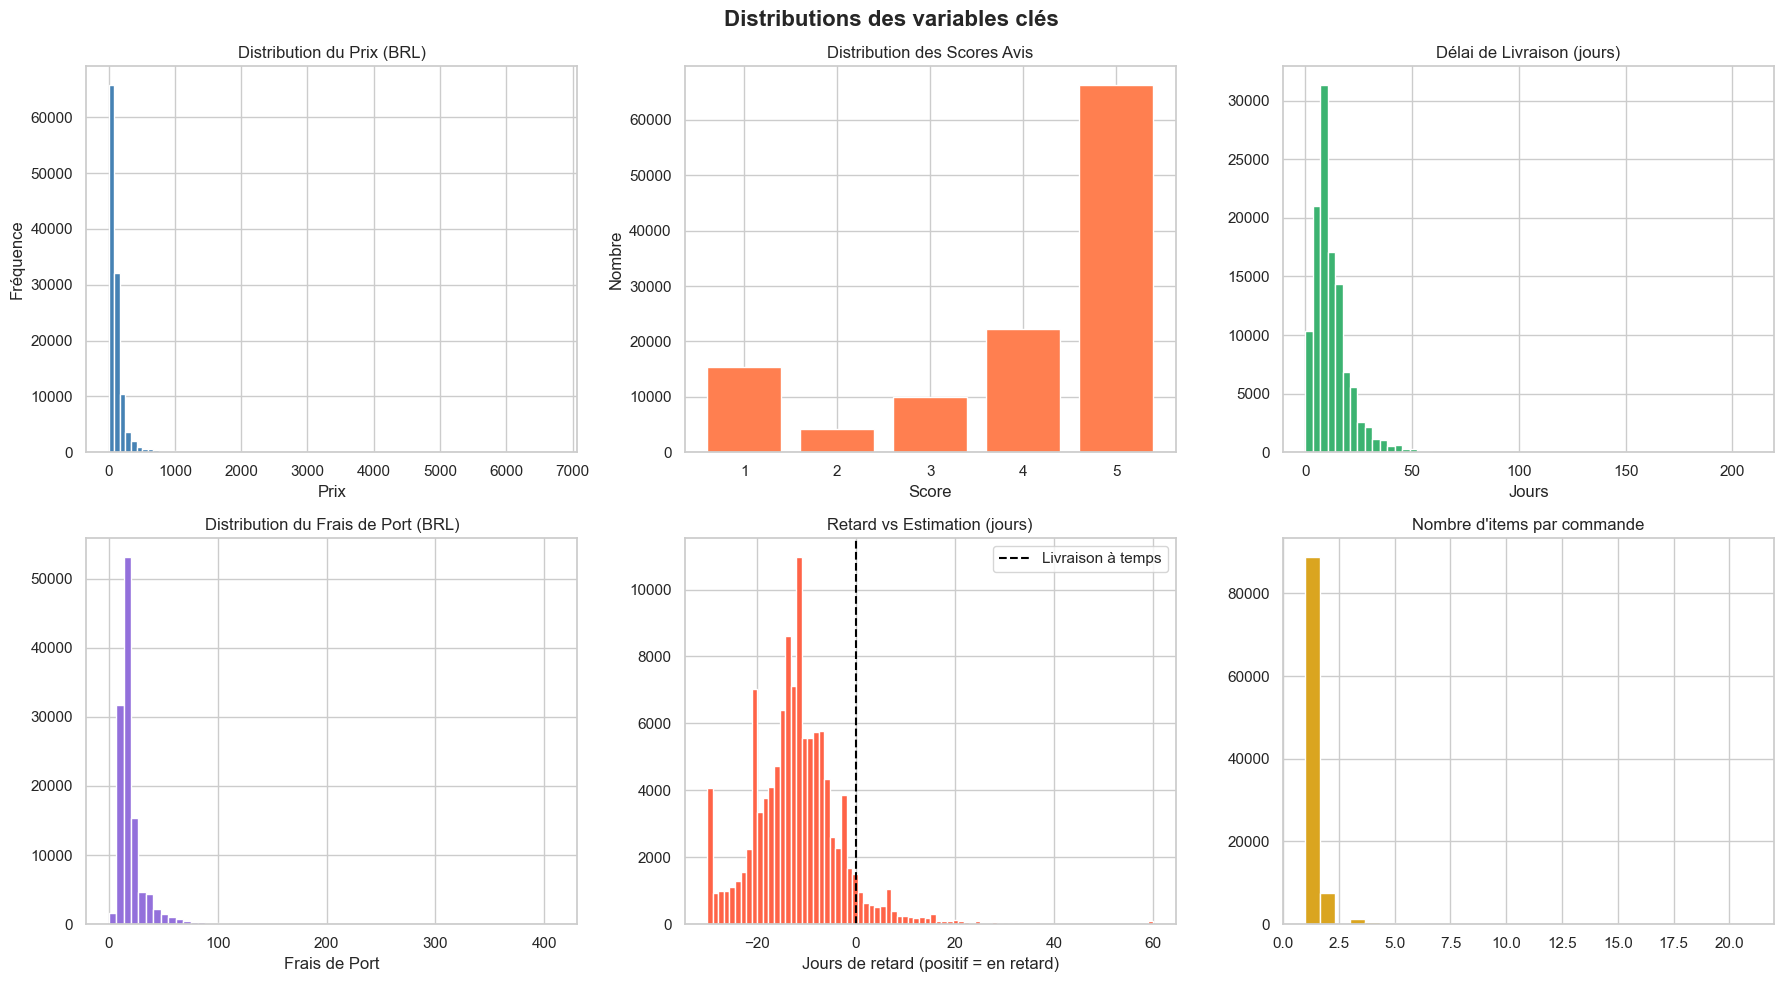

In [40]:
# ── 4. ANALYSE DES DISTRIBUTIONS ────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distributions des variables clés", fontsize=16, fontweight='bold')

# 4.1 Prix
axes[0,0].hist(df['price'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution du Prix (BRL)')
axes[0,0].set_xlabel('Prix'); axes[0,0].set_ylabel('Fréquence')

# 4.2 Score avis
review_counts = df['review_score'].value_counts().sort_index()
axes[0,1].bar(review_counts.index, review_counts.values, color='coral')
axes[0,1].set_title('Distribution des Scores Avis')
axes[0,1].set_xlabel('Score'); axes[0,1].set_ylabel('Nombre')

# 4.3 Délai livraison
axes[0,2].hist(df['delivery_days'].dropna(), bins=60, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Délai de Livraison (jours)')
axes[0,2].set_xlabel('Jours')

# 4.4 Freight value
axes[1,0].hist(df['freight_value'].dropna(), bins=60, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Distribution du Frais de Port (BRL)')
axes[1,0].set_xlabel('Frais de Port')

# 4.5 Retard (delay_days)
axes[1,1].hist(df['delay_days'].dropna().clip(-30, 60), bins=80, color='tomato', edgecolor='white')
axes[1,1].axvline(0, color='black', linestyle='--', label='Livraison à temps')
axes[1,1].set_title('Retard vs Estimation (jours)')
axes[1,1].set_xlabel('Jours de retard (positif = en retard)')
axes[1,1].legend()

# 4.6 Nombre d'items par commande
items_per_order = df.groupby('order_id')['order_item_id'].max()
axes[1,2].hist(items_per_order, bins=30, color='goldenrod', edgecolor='white')
axes[1,2].set_title("Nombre d'items par commande")

plt.tight_layout()
plt.savefig('../reports/figures/phase3_distributions.png', dpi=150)
plt.show()

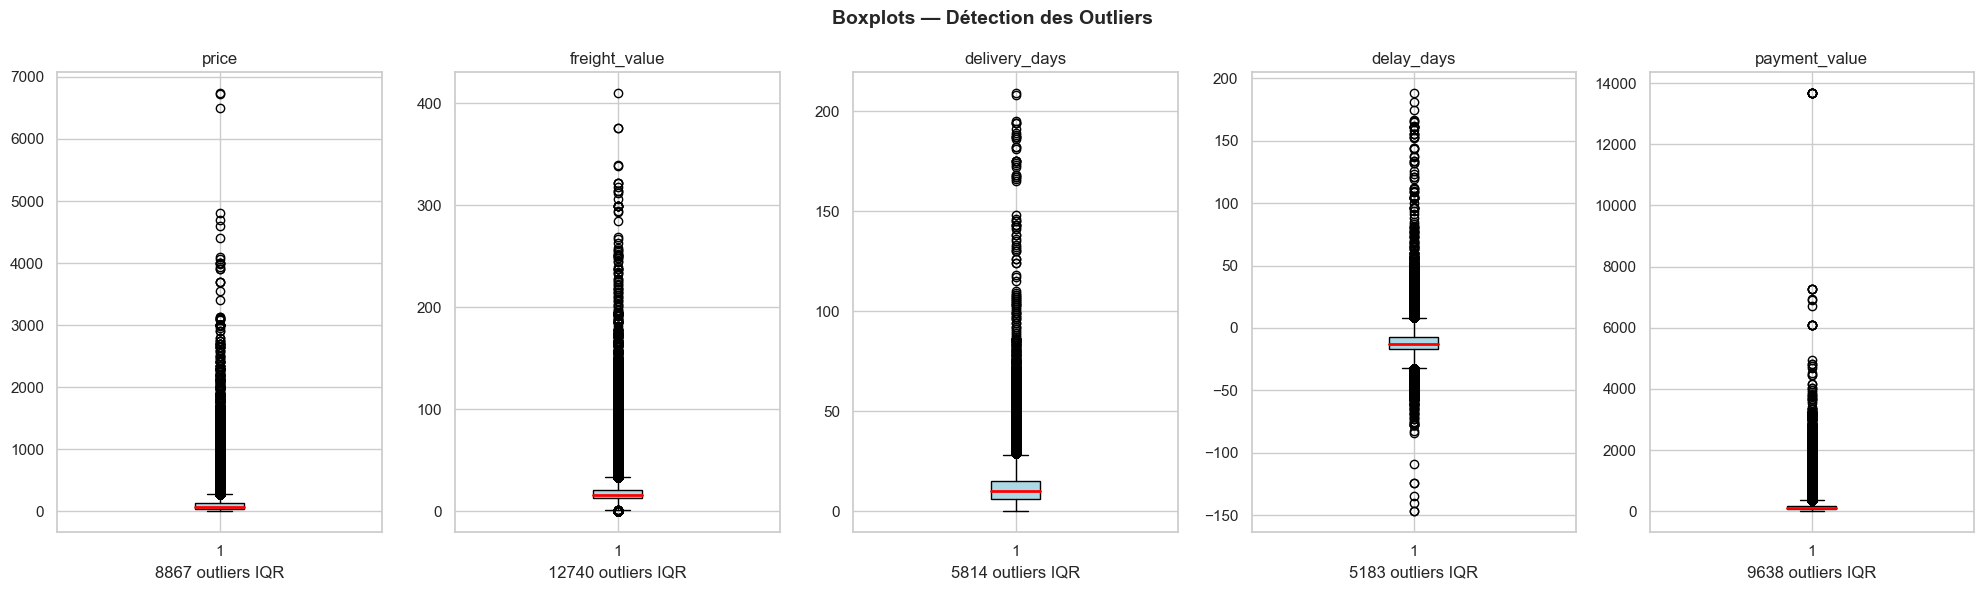

price : cap au 99e pctile = 895.00 BRL
freight_value : cap au 99e pctile = 84.94 BRL
payment_value : cap au 99e pctile = 1222.89 BRL


In [41]:
# ── 5. DÉTECTION DES OUTLIERS (Boxplots & IQR) ──────────────

num_cols = ['price', 'freight_value', 'delivery_days', 'delay_days', 'payment_value']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 6))
fig.suptitle("Boxplots — Détection des Outliers", fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    axes[i].set_xlabel(f'{n_outliers} outliers IQR')

plt.tight_layout()
plt.savefig('../reports/figures/phase3_boxplots.png', dpi=150)
plt.show()

# Traitement : on cap les outliers au 99e percentile pour les analyses suivantes
for col in ['price', 'freight_value', 'payment_value']:
    cap = df[col].quantile(0.99)
    df[f'{col}_capped'] = df[col].clip(upper=cap)
    print(f"{col} : cap au 99e pctile = {cap:.2f} BRL")

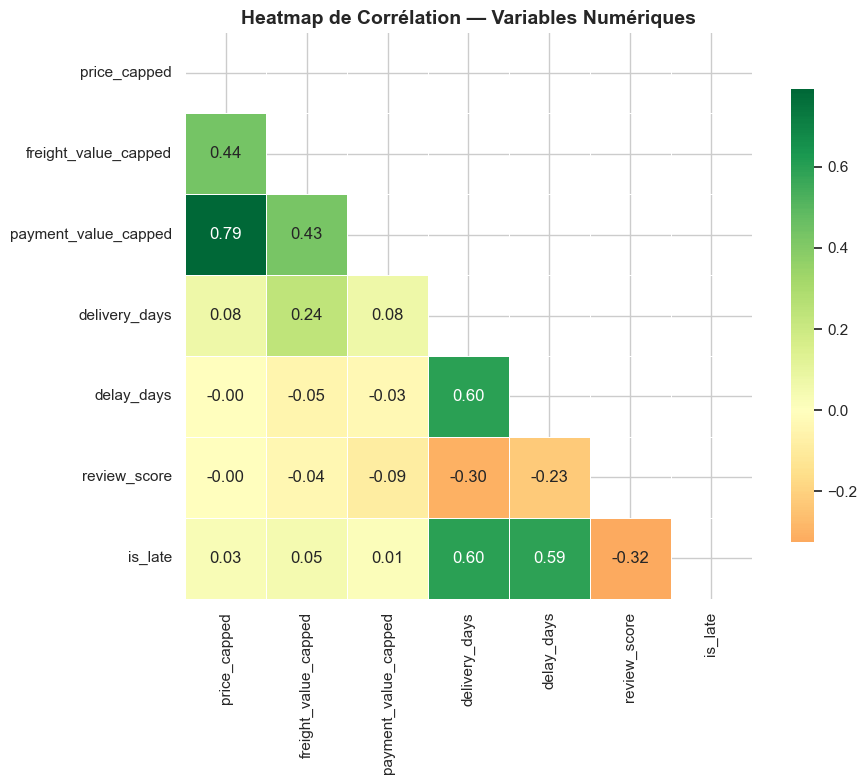


Top corrélations avec review_score :
is_late                -0.324518
delivery_days          -0.302750
delay_days             -0.228449
payment_value_capped   -0.088321
freight_value_capped   -0.040722
price_capped           -0.002114
review_score            1.000000
Name: review_score, dtype: float64


In [42]:
# ── 6. ANALYSE DE CORRÉLATION ────────────────────────────────

corr_cols = ['price_capped', 'freight_value_capped', 'payment_value_capped',
             'delivery_days', 'delay_days', 'review_score', 'is_late']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Heatmap de Corrélation — Variables Numériques", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/phase3_correlation_heatmap.png', dpi=150)
plt.show()

print("\nTop corrélations avec review_score :")
print(corr_matrix['review_score'].sort_values())

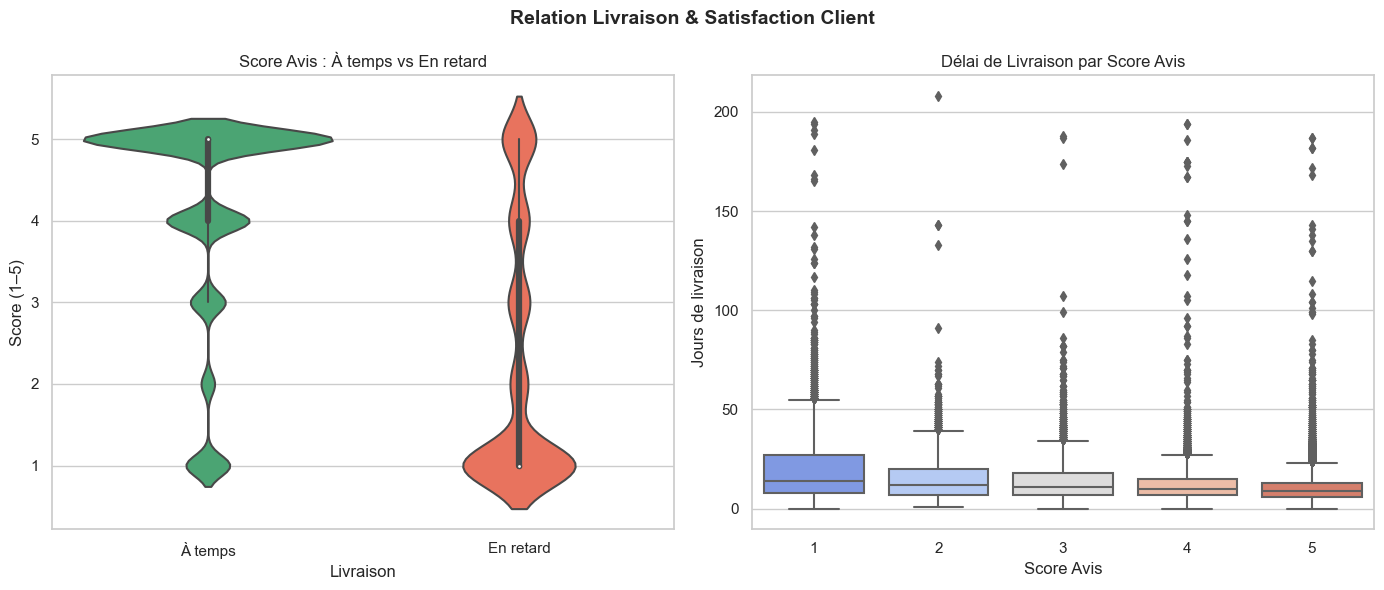

In [43]:
# ── 7. VIOLIN PLOTS — Score Avis vs Retard ───────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Relation Livraison & Satisfaction Client", fontsize=14, fontweight='bold')

# 7.1 Violin : score vs is_late
df_sample = df[['review_score', 'is_late']].dropna()
df_sample['Livraison'] = df_sample['is_late'].map({0: 'À temps', 1: 'En retard'})
sns.violinplot(data=df_sample, x='Livraison', y='review_score',
               palette=['mediumseagreen', 'tomato'], ax=axes[0])
axes[0].set_title('Score Avis : À temps vs En retard')
axes[0].set_ylabel('Score (1–5)')

# 7.2 Box : delivery_days par score
df_clean = df[['review_score', 'delivery_days']].dropna()
df_clean['review_score'] = df_clean['review_score'].astype(int)
sns.boxplot(data=df_clean, x='review_score', y='delivery_days',
            palette='coolwarm', ax=axes[1])
axes[1].set_title('Délai de Livraison par Score Avis')
axes[1].set_xlabel('Score Avis'); axes[1].set_ylabel('Jours de livraison')

plt.tight_layout()
plt.savefig('../reports/figures/phase3_violin_delivery_score.png', dpi=150)
plt.show()

In [44]:
# ── 8. TESTS STATISTIQUES ────────────────────────────────────

print("="*60)
print("TEST 1 — Mann-Whitney U : Score avis (à temps vs en retard)")
print("="*60)
on_time = df[df['is_late'] == 0]['review_score'].dropna()
late    = df[df['is_late'] == 1]['review_score'].dropna()
stat, p = stats.mannwhitneyu(on_time, late, alternative='greater')
print(f"  U-stat = {stat:.0f},  p-value = {p:.2e}")
print(f"  → {'Différence significative ✅' if p < 0.05 else 'Pas de différence significative'}")
print(f"  Médianes : à temps = {on_time.median():.1f}, en retard = {late.median():.1f}\n")

print("="*60)
print("TEST 2 — ANOVA : Délai de livraison selon le score avis")
print("="*60)
groups = [df[df['review_score'] == s]['delivery_days'].dropna() for s in [1,2,3,4,5]]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"  F-stat = {f_stat:.2f},  p-value = {p_anova:.2e}")
print(f"  → {'Différences significatives entre groupes ✅' if p_anova < 0.05 else 'Pas de différence'}\n")

print("="*60)
print("TEST 3 — Chi-² : Retard vs État du client (top 5 états)")
print("="*60)
top_states = df['customer_state'].value_counts().head(5).index
df_chi = df[df['customer_state'].isin(top_states)][['customer_state','is_late']].dropna()
contingency = pd.crosstab(df_chi['customer_state'], df_chi['is_late'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"  Chi² = {chi2:.2f},  p-value = {p_chi:.2e},  ddl = {dof}")
print(f"  → {'Association significative ✅' if p_chi < 0.05 else 'Pas d association'}")

TEST 1 — Mann-Whitney U : Score avis (à temps vs en retard)
  U-stat = 649645239,  p-value = 0.00e+00
  → Différence significative ✅
  Médianes : à temps = 5.0, en retard = 1.0

TEST 2 — ANOVA : Délai de livraison selon le score avis
  F-stat = 2961.33,  p-value = 0.00e+00
  → Différences significatives entre groupes ✅

TEST 3 — Chi-² : Retard vs État du client (top 5 états)
  Chi² = 1218.93,  p-value = 1.26e-262,  ddl = 4
  → Association significative ✅


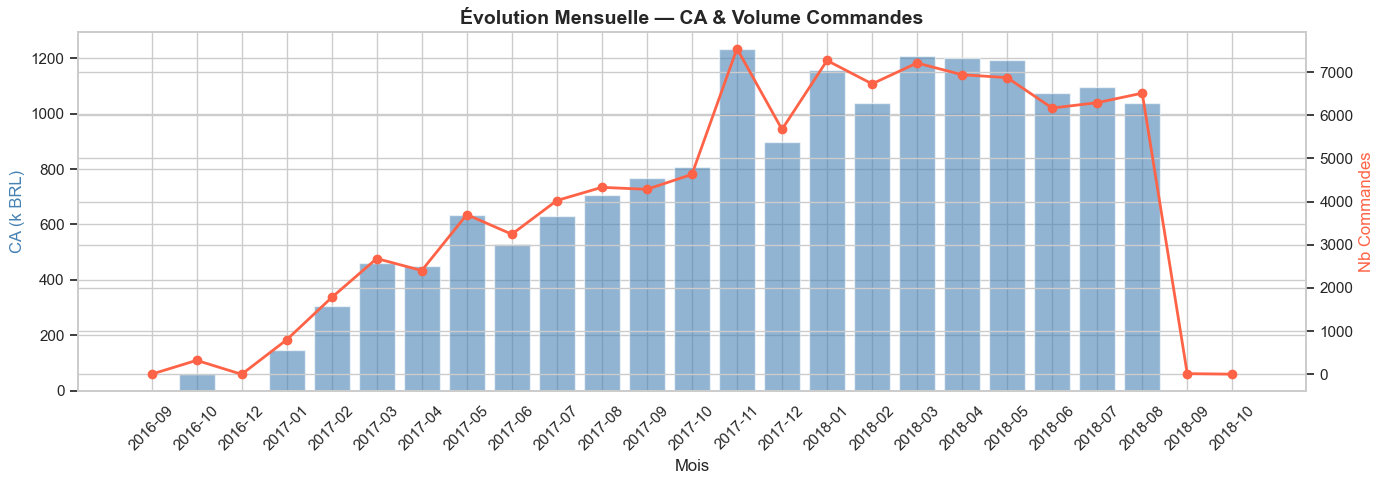

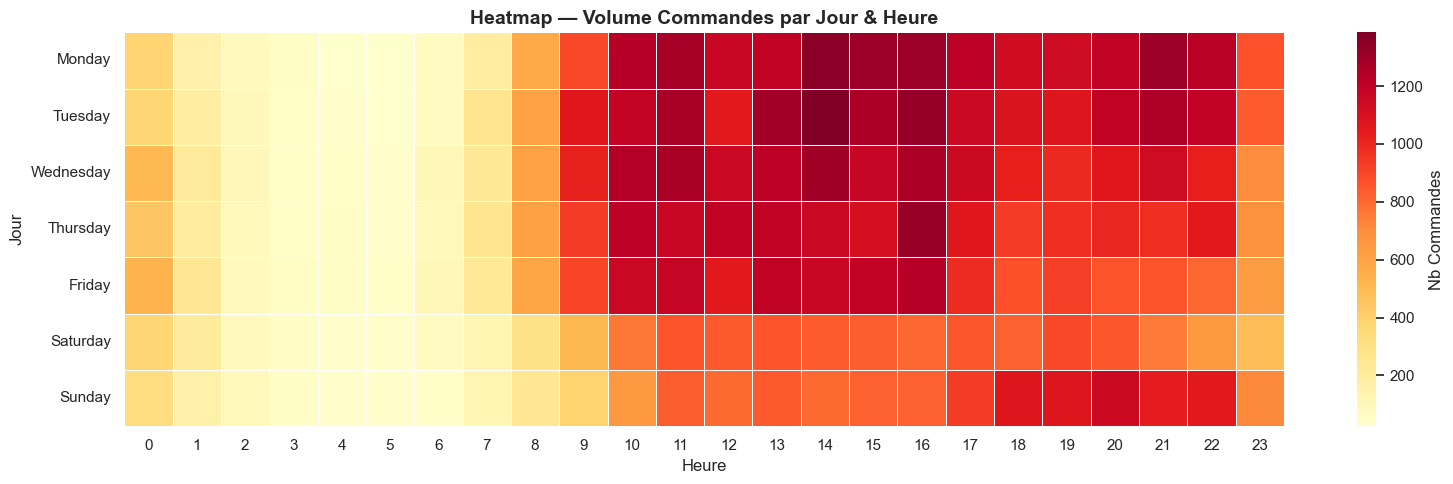

In [45]:
# ── 9. ANALYSE TEMPORELLE ────────────────────────────────────

# 9.1 Évolution mensuelle du CA
monthly = (df.groupby('order_month')
             .agg(revenue=('revenue','sum'), orders=('order_id','nunique'))
             .reset_index()
             .sort_values('order_month'))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['order_month'], monthly['revenue']/1000, color='steelblue', alpha=0.6, label='CA (k BRL)')
ax2.plot(monthly['order_month'], monthly['orders'], color='tomato', linewidth=2, marker='o', label='Nb commandes')
ax1.set_xlabel('Mois'); ax1.set_ylabel('CA (k BRL)', color='steelblue')
ax2.set_ylabel('Nb Commandes', color='tomato')
plt.title("Évolution Mensuelle — CA & Volume Commandes", fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.savefig('../reports/figures/phase3_monthly_trend.png', dpi=150)
plt.show()

# 9.2 Heatmap commandes par jour/heure
heatmap_data = df.groupby(['order_dow', 'order_hour'])['order_id'].count().unstack()
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5,
            cbar_kws={"label": "Nb Commandes"})
plt.title("Heatmap — Volume Commandes par Jour & Heure", fontsize=14, fontweight='bold')
plt.xlabel('Heure'); plt.ylabel('Jour')
plt.tight_layout()
plt.savefig('../reports/figures/phase3_heatmap_dow_hour.png', dpi=150)
plt.show()

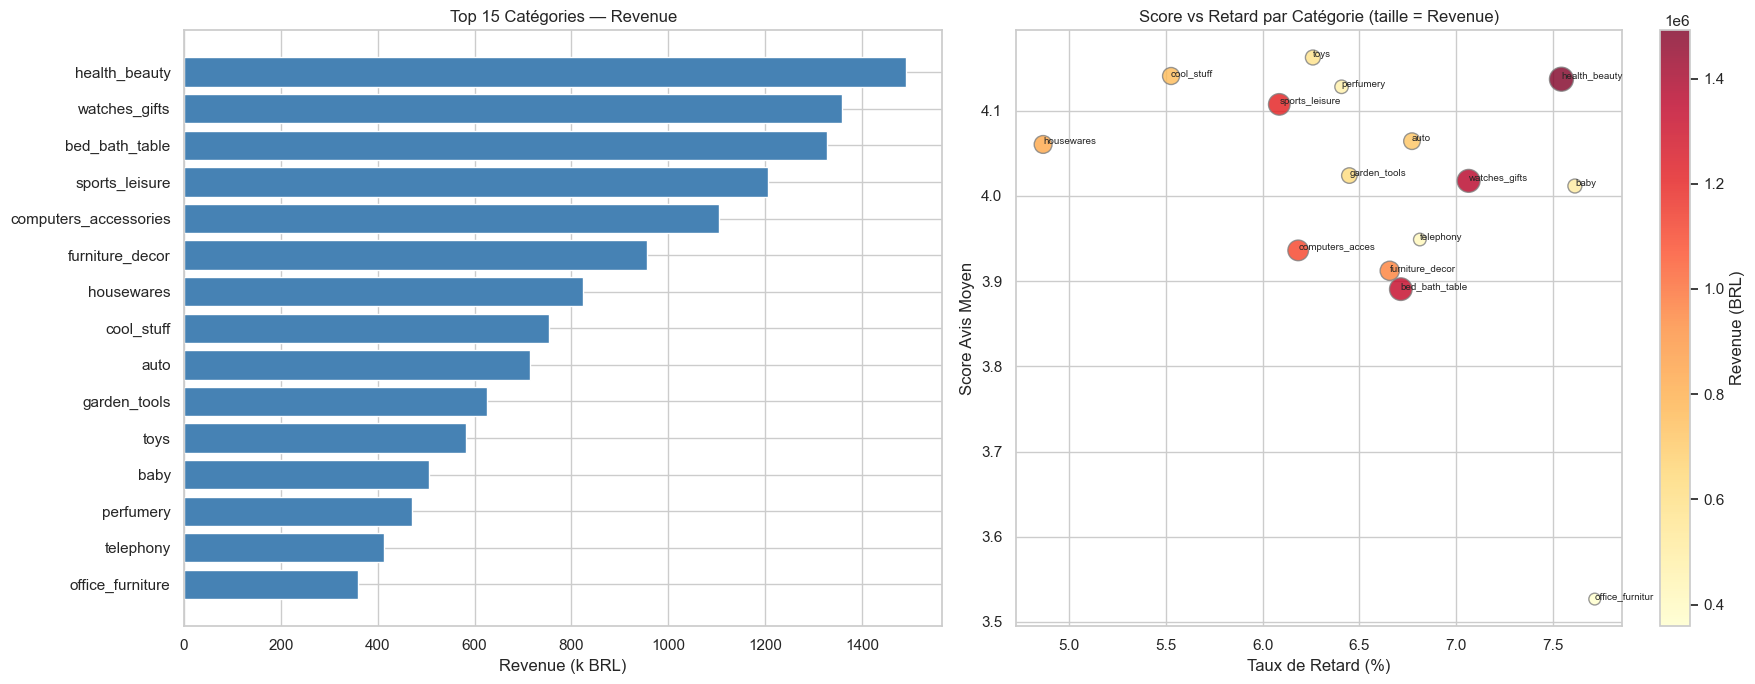

In [46]:
# ── 10. TOP CATÉGORIES ───────────────────────────────────────

cat_perf = (df.groupby('product_category_name_english')
              .agg(
                  revenue=('revenue','sum'),
                  orders=('order_id','nunique'),
                  avg_score=('review_score','mean'),
                  late_rate=('is_late','mean')
              )
              .dropna()
              .sort_values('revenue', ascending=False)
              .head(15)
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Revenu par catégorie
axes[0].barh(cat_perf['product_category_name_english'], cat_perf['revenue']/1000, color='steelblue')
axes[0].set_xlabel('Revenue (k BRL)'); axes[0].set_title('Top 15 Catégories — Revenue')
axes[0].invert_yaxis()

# Score moyen vs taux de retard (scatter)
sc = axes[1].scatter(cat_perf['late_rate']*100, cat_perf['avg_score'],
                     s=cat_perf['revenue']/5000, c=cat_perf['revenue'],
                     cmap='YlOrRd', alpha=0.8, edgecolors='gray')
for _, row in cat_perf.iterrows():
    axes[1].annotate(row['product_category_name_english'][:15],
                     (row['late_rate']*100, row['avg_score']), fontsize=7)
axes[1].set_xlabel('Taux de Retard (%)'); axes[1].set_ylabel('Score Avis Moyen')
axes[1].set_title('Score vs Retard par Catégorie (taille = Revenue)')
plt.colorbar(sc, ax=axes[1], label='Revenue (BRL)')

plt.tight_layout()
plt.savefig('../reports/figures/phase3_category_analysis.png', dpi=150)
plt.show()

In [47]:
# ── 11. SEGMENTATION CLIENT — RFM ───────────────────────────

snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (df.groupby('customer_unique_id')
         .agg(
             recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
             frequency=('order_id', 'nunique'),
             monetary=('revenue', 'sum')
         )
         .reset_index())

print(f"Table RFM : {rfm.shape}")
rfm.describe()

Table RFM : (96096, 4)


,recency,frequency,monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,173.199002
std,153.414676,0.214384,264.150404
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.270000
50%,269.000000,1.000000,109.820000
75%,398.000000,1.000000,188.200000
max,773.000000,17.000000,13664.080000


  K=2 → inertia=207835  |  silhouette=0.7402
  K=3 → inertia=142254  |  silhouette=0.4636
  K=4 → inertia=99050  |  silhouette=0.4935
  K=5 → inertia=83484  |  silhouette=0.5022
  K=6 → inertia=68627  |  silhouette=0.4524
  K=7 → inertia=58961  |  silhouette=0.4547
  K=8 → inertia=49377  |  silhouette=0.4585


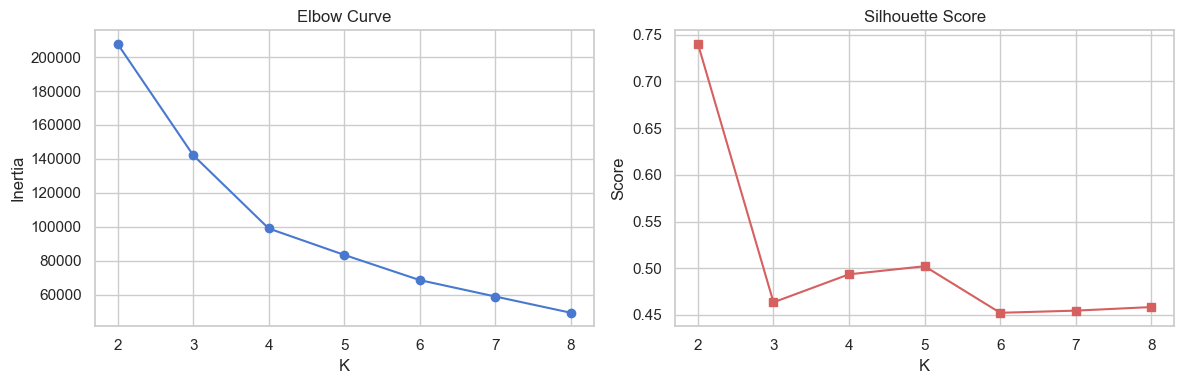


✅ K optimal retenu : 2  (silhouette = 0.740)


In [48]:
# ── 12. CLUSTERING K-MEANS ──────────────────────────────────

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Normalisation
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# ✅ Sample très réduit : 2000 points max
SAMPLE_SIZE = 2000
np.random.seed(42)
sample_idx  = np.random.choice(len(rfm_scaled), size=min(SAMPLE_SIZE, len(rfm_scaled)), replace=False)
rfm_sample  = rfm_scaled[sample_idx]

# Elbow + Silhouette
inertias, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)                          # fit sur tout le dataset
    inertias.append(km.inertia_)

    labels_sample = km.predict(rfm_sample)      # predict sur le petit sample
    # ✅ sample_size intégré pour double sécurité
    sil = silhouette_score(rfm_sample, labels_sample, sample_size=2000, random_state=42)
    sil_scores.append(sil)
    print(f"  K={k} → inertia={km.inertia_:.0f}  |  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Curve'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sil_scores, 'rs-')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
plt.tight_layout()
plt.savefig('../reports/figures/phase3_elbow_silhouette.png', dpi=150)
plt.show()

k_opt = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"\n✅ K optimal retenu : {k_opt}  (silhouette = {max(sil_scores):.3f})")

         recency  frequency  monetary   size   pct
cluster                                           
0         289.36        1.0    165.46  93068  96.8
1         269.45        2.1    411.16   3028   3.2


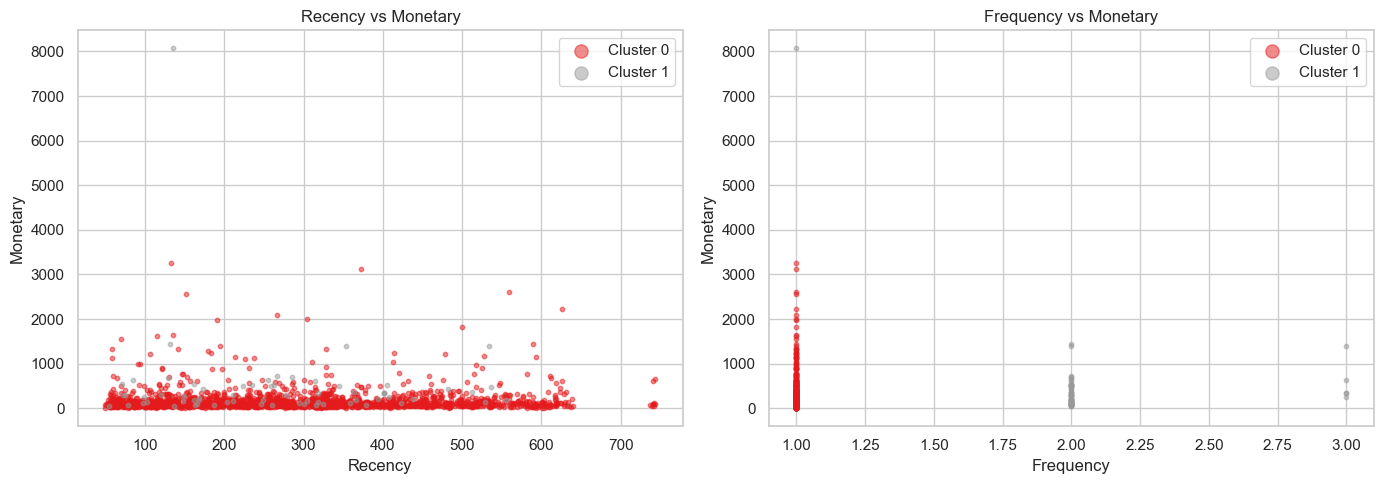

In [49]:
# K final — fit sur tout le dataset
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Profil des clusters
cluster_profile = rfm.groupby('cluster')[['recency','frequency','monetary']].mean().round(2)
cluster_profile['size'] = rfm.groupby('cluster').size()
cluster_profile['pct']  = (cluster_profile['size'] / len(rfm) * 100).round(1)
print(cluster_profile)

# Visualisation — scatter sur sample léger
sample_viz = rfm.sample(2000, random_state=42)
colors = plt.cm.Set1(np.linspace(0, 1, k_opt))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cid in range(k_opt):
    mask = sample_viz['cluster'] == cid
    axes[0].scatter(sample_viz[mask]['recency'],   sample_viz[mask]['monetary'],
                    alpha=0.5, s=10, color=colors[cid], label=f'Cluster {cid}')
    axes[1].scatter(sample_viz[mask]['frequency'], sample_viz[mask]['monetary'],
                    alpha=0.5, s=10, color=colors[cid], label=f'Cluster {cid}')

axes[0].set_xlabel('Recency'); axes[0].set_ylabel('Monetary')
axes[0].set_title('Recency vs Monetary'); axes[0].legend(markerscale=3)
axes[1].set_xlabel('Frequency'); axes[1].set_ylabel('Monetary')
axes[1].set_title('Frequency vs Monetary'); axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('../reports/figures/phase3_clusters_rfm.png', dpi=150)
plt.show()

In [50]:
# ── 13. DBSCAN ──────────────────────────────────────────────
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10).fit(rfm_sample)   # rfm_sample = 2000 pts
n_anomalies = (db.labels_ == -1).sum()
print(f"DBSCAN sur {len(rfm_sample)} clients")
print(f"Anomalies : {n_anomalies} ({n_anomalies/len(rfm_sample)*100:.1f}%)")
print(f"Clusters  : {len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)}")

DBSCAN sur 2000 clients
Anomalies : 94 (4.7%)
Clusters  : 2


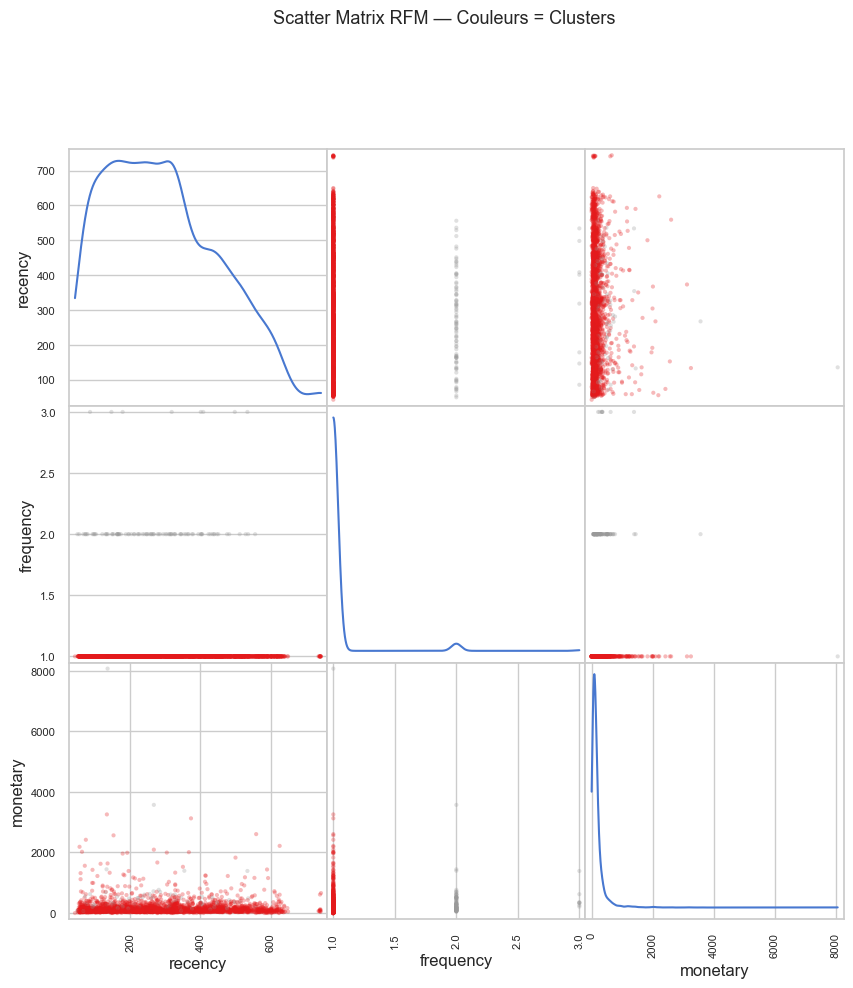

In [51]:
# ── 14. SCATTER MATRIX ──────────────────────────────────────

sample = rfm.sample(min(3000, len(rfm)), random_state=42)
pd.plotting.scatter_matrix(
    sample[['recency','frequency','monetary']],
    c=sample['cluster'], cmap='Set1',
    alpha=0.3, figsize=(10,10), diagonal='kde'
)
plt.suptitle("Scatter Matrix RFM — Couleurs = Clusters", y=1.02, fontsize=13)
plt.savefig('../reports/figures/phase3_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ── 15. EXPORT DES DONNÉES ENRICHIES ────────────────────────

rfm.to_csv('../data/processed/rfm_clusters.csv', index=False)
df.to_csv('../data/processed/master_table.csv', index=False)

print("✅ Phase 3 terminée — fichiers sauvegardés :")
print("  → data/processed/rfm_clusters.csv")
print("  → data/processed/master_table.csv")
print("  → reports/figures/phase3_*.png")

✅ Phase 3 terminée — fichiers sauvegardés :
  → data/processed/rfm_clusters.csv
  → data/processed/master_table.csv
  → reports/figures/phase3_*.png
